<a href="https://colab.research.google.com/github/Murtuzasaifee/transformer_finetuning/blob/master/GPT_News_Classification_FineTuning_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📰 News Topic Classification Fine-Tuning with GPT (2026 Standards)

**Complete Classroom Implementation**

In this notebook, you'll learn how to fine-tune a pre-trained **GPT model** for text classification using the Hugging Face Transformers library.

## What You'll Learn:
1. ✅ Load and explore a news topic dataset
2. ✅ Tokenize text data for GPT (with key differences from BERT!)
3. ✅ Configure and train a GPT classification model
4. ✅ Evaluate model performance with confusion matrix
5. ✅ Make predictions on custom news headlines
6. ✅ Save and load your fine-tuned model

## Task:
**4-Class News Topic Classification** (World, Sports, Business, Sci/Tech) on the AG News benchmark

## ⚠️ This notebook is a companion to the BERT Sentiment notebook!
Both notebooks follow the **same 9-phase structure** so you can directly compare:
- BERT on tweets (3 classes, ~66M params) → this notebook
- GPT on news (4 classes, ~82M params) ← you are here

---
**Prerequisites**: Basic Python knowledge and familiarity with machine learning concepts.

In [1]:
# ============================================================
# Package Installation with UV (2026 standard)
# ============================================================
# Works in Google Colab (--system) and in a local uv venv.
# Locally you can also run: uv pip install <packages> in your terminal.
# import sys
# import subprocess

# IS_COLAB = "google.colab" in sys.modules

# def uv_install(*packages):
#     """Install packages with uv (adds --system automatically in Colab)."""
#     cmd = ["uv", "pip", "install"] + (["--system"] if IS_COLAB else []) + list(packages)
#     print(" ".join(cmd))
#     subprocess.run(cmd, check=True)

# uv_install(
#     "transformers",   # 5.x — latest
#     "datasets",       # 5.x — latest
#     "evaluate",
#     "accelerate",
#  #   "seqeval",
#     "matplotlib",
#     "seaborn",
#     "scikit-learn",
#     "pandas",
#     "numpy",
#     # "torch",        # uncomment locally if torch is missing (Colab ships it)
# )
# print("✅ All packages installed successfully!")


## 📦 Phase 1: Environment Setup

First, let's install the required packages. These are the **2026 standard versions** of the libraries.

In [2]:
# ============================================================
# Library Import Verification - FIXED
# ============================================================

import sys

def check_import(library_name, version_attr="__version__"):  # ✅ Removed unused import_statement
    try:
        module = __import__(library_name)
        version = getattr(module, version_attr, "version unknown")
        print(f"✅ {library_name:<20} version: {version}")
        return True
    except ImportError as e:
        print(f"❌ {library_name:<20} FAILED - {e}")
        return False

print("=" * 55)
print("       Library Import Verification Check")
print("=" * 55)
print(f"Python version: {sys.version}\n")

results = {}

# --- Core Libraries ---
print("📦 Core Libraries:")
results["transformers"]   = check_import("transformers")
results["datasets"]       = check_import("datasets")
results["evaluate"]       = check_import("evaluate")
results["accelerate"]     = check_import("accelerate")

# --- Evaluation ---
# print("\n📊 Evaluation:")
# try:
#     import seqeval
#     print(f"✅ {'seqeval':<20} imported successfully")
#     results["seqeval"] = True
# except ImportError as e:
#     print(f"❌ {'seqeval':<20} FAILED - {e}")
#     results["seqeval"] = False

# --- Visualization ---
print("\n🎨 Visualization:")
results["matplotlib"]     = check_import("matplotlib")
results["seaborn"]        = check_import("seaborn")

# --- Data & ML ---
print("\n🔢 Data & ML:")
results["sklearn"]        = check_import("sklearn")
results["pandas"]         = check_import("pandas")
results["numpy"]          = check_import("numpy")

# --- Deep Learning ---
print("\n🤖 Deep Learning:")
try:
    import torch
    print(f"✅ {'torch':<20} version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
    results["torch"] = True
except ImportError as e:
    print(f"❌ {'torch':<20} FAILED - {e}")
    results["torch"] = False

# --- Summary ---
print("\n" + "=" * 55)
passed = sum(results.values())
total  = len(results)

if passed == total:
    print(f"✅ All {total}/{total} libraries imported successfully!")
else:
    print(f"⚠️  {passed}/{total} libraries passed")
    failed = [lib for lib, ok in results.items() if not ok]
    print(f"❌ Failed libraries: {', '.join(failed)}")
    print("\n💡 Fix failed installs with:")
    for lib in failed:
        print(f"   !uv pip install {lib}")

print("=" * 55)

       Library Import Verification Check
Python version: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:09:17) [GCC 11.2.0]

📦 Core Libraries:


✅ transformers         version: 5.17.0
✅ datasets             version: 5.0.1
✅ evaluate             version: 0.4.6
✅ accelerate           version: 1.15.0

🎨 Visualization:
✅ matplotlib           version: 3.8.2
✅ seaborn              version: 0.13.2

🔢 Data & ML:
✅ sklearn              version: 1.3.2
✅ pandas               version: 2.1.4
✅ numpy                version: 1.26.4

🤖 Deep Learning:
✅ torch                version: 2.8.0+cu128
   CUDA available: True
   GPU: Tesla T4

✅ All 10/10 libraries imported successfully!


In [3]:
!pip install evaluate

### GPU Check

Let's check if we have a GPU available. Training is **much faster** with GPU!
> Go to **Runtime → Change runtime type → T4 GPU** if you don't see GPU below.

In [4]:
# ============================================================
# Device Selection — local Apple Silicon (MPS) or Colab GPU (CUDA)
# ============================================================
import torch

FORCE_DEVICE = "cuda"   # <-- set "cuda" for Colab GPU, "mps" for Apple Silicon, None = auto

def pick_device():
    if FORCE_DEVICE:
        return torch.device(FORCE_DEVICE)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = pick_device()

print("=" * 60)
print("DEVICE CONFIGURATION")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available:  {torch.backends.mps.is_available()}")

if device.type == "cuda":
    print(f"\n✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   BF16 supported: {torch.cuda.is_bf16_supported()}")
elif device.type == "mps":
    print("\n✅ Apple Silicon GPU detected — using MPS acceleration")
else:
    print("\n⚠️ No GPU detected. Training will run on CPU (slower).")
    print("   Colab: Runtime > Change runtime type > T4 GPU")

print(f"\n📍 Using device: {device}")
print("=" * 60)


DEVICE CONFIGURATION
PyTorch version: 2.8.0+cu128
CUDA available: True
MPS available:  False

✅ GPU detected: Tesla T4
   GPU memory: 15.64 GB
   BF16 supported: True

📍 Using device: cuda


### Import Libraries

In [5]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.metrics import classification_report, confusion_matrix

# Hugging Face libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from datasets import load_dataset
import evaluate

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### 🤖 BERT vs GPT — What's Different?

Before we start, let's understand the key architectural differences. This will explain some **unusual setup steps** you'll see in this notebook.

| Feature | BERT (Encoder) | GPT (Decoder) |
|---------|----------------|---------------|
| **Architecture** | Transformer Encoder | Transformer Decoder |
| **Attention type** | Bidirectional — every token attends to all other tokens | Causal (left-to-right) — each token only attends to previous tokens |
| **Pretraining task** | Masked Language Modeling (MLM) | Causal Language Modeling (CLM) |
| **Pad token** | Has `[PAD]` token built-in | **No pad token!** → must manually set `eos_token` as pad |
| **Padding side** | Right-padding (natural for BERT) | **Left-padding required** (so the sequence ends at EOS for classification) |
| **Token type IDs** | Yes (`[CLS]`, `[SEP]`, segment IDs) | No (GPT just has token IDs) |
| **Best for** | Understanding tasks (classification, NER, QA) | Generation tasks (text completion, chat) |
| **Fine-tuning for classification** | Natural fit (uses `[CLS]` token) | Works but needs special handling (uses last token) |

> **Key insight**: GPT's causal attention means it reads text **left-to-right only**. For classification, the prediction is based on the **last token**, so we need **left-padding** — padding goes at the start, not the end.

### Configuration

In [6]:
# Model configuration
MODEL_NAME = "distilgpt2"  # 82M params, ~328 MB, fast on free Colab T4
# MODEL_NAME = "gpt2"      # 124M params, more capable but slower

# Dataset configuration
DATASET_NAME = "fancyzhx/ag_news"

# Subset sizes (balanced, fast to train)
TRAIN_SIZE = 2400   # 600 per class
VAL_SIZE   = 400    # 100 per class
TEST_SIZE  = 1000   # 250 per class

# Training hyperparameters (mirrors BERT notebook exactly)
LEARNING_RATE = 2e-5      # Standard for fine-tuning
BATCH_SIZE    = 16        # Batch size for training
NUM_EPOCHS    = 3         # Number of training epochs
WEIGHT_DECAY  = 0.01      # Regularization
MAX_LENGTH    = 128       # Maximum sequence length

# Label configuration (AG News 4 classes)
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
NUM_LABELS  = len(LABEL_NAMES)

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET_NAME}")
print(f"Number of classes: {NUM_LABELS}")
print(f"Labels: {LABEL_NAMES}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print("=" * 60)

CONFIGURATION
Model: distilgpt2
Dataset: fancyzhx/ag_news
Number of classes: 4
Labels: ['World', 'Sports', 'Business', 'Sci/Tech']
Learning rate: 2e-05
Batch size: 16
Epochs: 3


## 📊 Phase 2: Data Loading and Exploration

### Load Dataset

We'll use the **AG News** dataset — a classic 4-class news topic benchmark.

- **World** (0) — international news and politics
- **Sports** (1) — sports news and events
- **Business** (2) — business and financial news
- **Sci/Tech** (3) — science and technology news

AG News has 120,000 training examples — we'll sample a balanced subset for speed.

In [7]:
print("Loading AG News dataset...")
raw_dataset = load_dataset(DATASET_NAME)

print("\n✅ Dataset loaded!")
print("\nFull dataset structure:")
print(raw_dataset)

Loading AG News dataset...


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


✅ Dataset loaded!

Full dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


### Create Balanced Splits

AG News only has train/test splits. We'll create a validation split and sample a balanced subset for faster training.

In [8]:
from datasets import DatasetDict

def sample_balanced(dataset_split, n_per_class, seed=SEED):
    """Sample n_per_class examples from each class, returning a balanced dataset."""
    indices = []
    labels = dataset_split["label"]
    for class_id in range(NUM_LABELS):
        class_indices = [i for i, l in enumerate(labels) if l == class_id]
        # Reproducible shuffle
        rng = np.random.default_rng(seed + class_id)
        chosen = rng.choice(class_indices, size=n_per_class, replace=False).tolist()
        indices.extend(chosen)
    # Shuffle so classes are interleaved — otherwise sequential slices
    # (e.g. val/test split below) would each contain only some classes.
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)
    return dataset_split.select(indices)

# Sample balanced subsets
train_per_class = TRAIN_SIZE // NUM_LABELS   # 600
val_per_class   = VAL_SIZE   // NUM_LABELS   # 100
test_per_class  = TEST_SIZE  // NUM_LABELS   # 250

train_data = sample_balanced(raw_dataset["train"], train_per_class)
test_full  = sample_balanced(raw_dataset["test"],  test_per_class + val_per_class)

# Split test into val + test
val_data  = test_full.select(range(VAL_SIZE))
test_data = test_full.select(range(VAL_SIZE, VAL_SIZE + TEST_SIZE))

dataset = DatasetDict({
    "train":      train_data,
    "validation": val_data,
    "test":       test_data
})

print("✅ Balanced splits created!")
print(f"\nDataset sizes:")
print(f"  Training set:   {len(dataset['train'])} samples  ({train_per_class}/class)")
print(f"  Validation set: {len(dataset['validation'])} samples ({val_per_class}/class)")
print(f"  Test set:       {len(dataset['test'])} samples ({test_per_class}/class)")

✅ Balanced splits created!

Dataset sizes:
  Training set:   2400 samples  (600/class)
  Validation set: 400 samples (100/class)
  Test set:       1000 samples (250/class)


### Explore Dataset

In [9]:
# Convert to DataFrame for exploration
train_df = dataset["train"].to_pandas()

print("Class Distribution (Training Set):")
print("-" * 40)
class_dist = train_df["label"].value_counts().sort_index()
for i, count in enumerate(class_dist):
    print(f"  {i}: {LABEL_NAMES[i]:10s}: {count:4d} samples ({100*count/len(train_df):.1f}%)")

print(f"\nText length statistics:")
train_df["text_len"] = train_df["text"].str.len()
print(f"  Mean:   {train_df['text_len'].mean():.0f} chars")
print(f"  Median: {train_df['text_len'].median():.0f} chars")
print(f"  Max:    {train_df['text_len'].max()} chars")

Class Distribution (Training Set):
----------------------------------------
  0: World     :  600 samples (25.0%)
  1: Sports    :  600 samples (25.0%)
  2: Business  :  600 samples (25.0%)
  3: Sci/Tech  :  600 samples (25.0%)

Text length statistics:
  Mean:   235 chars
  Median: 233 chars
  Max:    659 chars


### Visualize Class Distribution

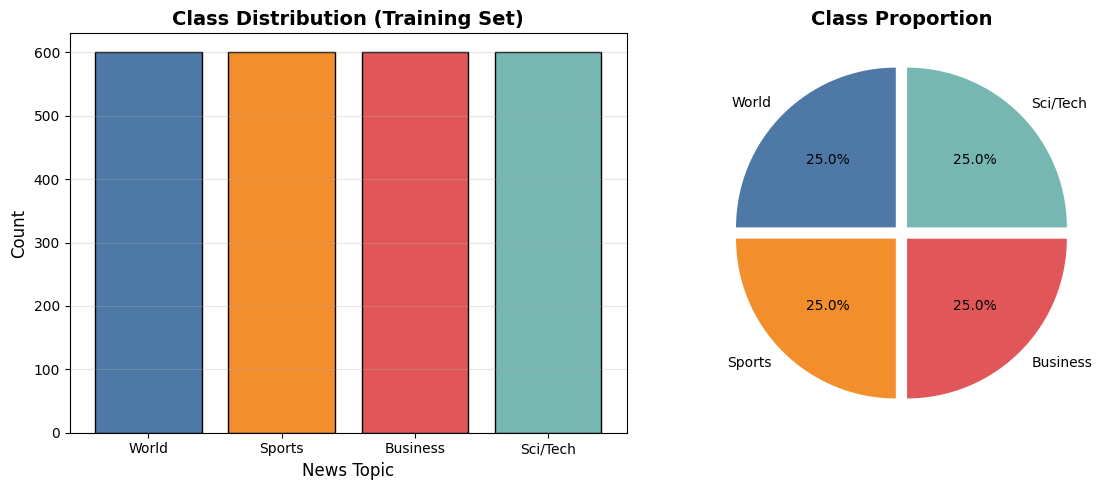


📊 Chart saved as 'class_distribution.png'


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

# Bar plot
counts = train_df["label"].value_counts().sort_index().values
axes[0].bar(LABEL_NAMES, counts, color=colors, edgecolor="black")
axes[0].set_title("Class Distribution (Training Set)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("News Topic", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].grid(axis="y", alpha=0.3)

# Pie chart
axes[1].pie(counts, labels=LABEL_NAMES, autopct="%1.1f%%",
            colors=colors, explode=[0.05]*4, startangle=90)
axes[1].set_title("Class Proportion", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Chart saved as 'class_distribution.png'")

### View Sample Examples

In [11]:
print("Sample Examples from Training Set:")
print("=" * 80)

for class_id in range(NUM_LABELS):
    sample_row = train_df[train_df["label"] == class_id].iloc[0]
    text = sample_row["text"]
    print(f"\nClass {class_id}: {LABEL_NAMES[class_id].upper()}")
    print(f"Text: \"{text[:120]}...\"")
    print("-" * 80)

Sample Examples from Training Set:

Class 0: WORLD
Text: "Pakistan Turns Up No Signs of Bin Laden Pakistan said Monday there was no evidence Osama bin Laden is hiding in the coun..."
--------------------------------------------------------------------------------

Class 1: SPORTS
Text: "Agassi moves into semis at Madrid Andre Agassi responded to a warm greeting by Spanish fans by eliminating the last loca..."
--------------------------------------------------------------------------------

Class 2: BUSINESS
Text: "Santander May Drop Abbey on Competition Inquiry, Telegraph Says Santander Central Hispano SA, the biggest bank in Spain ..."
--------------------------------------------------------------------------------

Class 3: SCI/TECH
Text: "Farming Killer Cone Snails a Risky Affair (AP) AP - Jon-Paul Bingham puts his life on the line every week for the sake o..."
--------------------------------------------------------------------------------


## 🔤 Phase 3: Tokenization

This is where GPT **differs most from BERT**. Pay close attention to the two special setup steps below.

### Load Tokenizer

In [12]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"\nTokenizer loaded!")
print(f"  Vocabulary size: {tokenizer.vocab_size:,}")
print(f"  EOS token:       '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")
print(f"  PAD token:       {tokenizer.pad_token}  (None = no pad token yet!)")

Loading tokenizer: distilgpt2


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


Tokenizer loaded!
  Vocabulary size: 50,257
  EOS token:       '<|endoftext|>' (id=50256)
  PAD token:       None  (None = no pad token yet!)


### ⚠️ GPT-Specific Setup: Pad Token and Left-Padding

GPT was designed for **text generation**, not classification. That means:

1. **No pad token by default** — GPT never needed to pad sequences during pretraining, so `tokenizer.pad_token` is `None`. We fix this by reusing the EOS token as the pad token.

2. **Left-padding is required** — GPT uses **causal (left-to-right) attention**. For classification, the model makes a prediction based on the **last token** in the sequence. If we pad on the right (like BERT does), the last token would always be a pad token — which is meaningless. Padding on the **left** ensures the actual text ends at position `[-1]`, giving the model a meaningful final token to base its prediction on.

```
BERT (right-padding):  [CLS] token1 token2 [PAD] [PAD]  ← prediction from [CLS]
GPT  (left-padding):   [PAD] [PAD]  token1 token2 <|endoftext|>  ← prediction from last real token
```

In [13]:
# GPT FIX 1: Set pad token = EOS token
# GPT has no pad token by default, so we reuse the EOS token for padding.
tokenizer.pad_token = tokenizer.eos_token

# GPT FIX 2: Use left-padding
# This ensures the actual text ends at the last position (where GPT makes its prediction).
tokenizer.padding_side = "left"

tokenizer.model_max_length = MAX_LENGTH

print("✅ GPT tokenizer configured!")
print(f"  PAD token:     '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"  Padding side:   {tokenizer.padding_side}")
print(f"  Max length:     {tokenizer.model_max_length}")

✅ GPT tokenizer configured!
  PAD token:     '<|endoftext|>' (id=50256)
  Padding side:   left
  Max length:     128


### Define Tokenization Function

In [14]:
def tokenize_function(examples):
    """
    Tokenize text examples for GPT.

    Note: GPT does NOT produce token_type_ids (unlike BERT),
    so the output will only have input_ids and attention_mask.
    """
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

print("✅ Tokenization function defined!")

✅ Tokenization function defined!


### Tokenize the Dataset

In [15]:
print("Tokenizing dataset...\n")

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing"
)

# Remove original text column
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Rename 'label' -> 'labels' (Trainer expects this name)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Set format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("✅ Tokenization complete!")
print(f"\nTokenized dataset features: {list(tokenized_datasets['train'].features.keys())}")
print("\nNotice: NO 'token_type_ids' (that's a BERT-only feature!)")

Tokenizing dataset...



Tokenizing:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1000 [00:00<?, ? examples/s]

✅ Tokenization complete!

Tokenized dataset features: ['labels', 'input_ids', 'attention_mask']

Notice: NO 'token_type_ids' (that's a BERT-only feature!)


### Verify Tokenization

In [16]:
sample = tokenized_datasets["train"][0]

print("Sample Tokenized Example (GPT):")
print("=" * 60)
print(f"Input IDs shape:      {sample['input_ids'].shape}")
print(f"Attention Mask shape: {sample['attention_mask'].shape}")
print(f"Label:                {sample['labels']} ({LABEL_NAMES[sample['labels']]})")

# Show padding side: left-padding means zeros appear at the START
attn = sample["attention_mask"].tolist()
first_real = attn.index(1)
print(f"\nLeft-padding verification:")
print(f"  First {first_real} tokens are padding (attention mask = 0)")
print(f"  Real content starts at position {first_real}")
print(f"  Last attention mask value: {attn[-1]} (should be 1 = real token)")
print(f"\nFirst 10 input IDs: {sample['input_ids'][:10].tolist()}")
print(f"First 10 attention: {attn[:10]}")

Sample Tokenized Example (GPT):
Input IDs shape:      torch.Size([128])
Attention Mask shape: torch.Size([128])
Label:                2 (Business)

Left-padding verification:
  First 68 tokens are padding (attention mask = 0)
  Real content starts at position 68
  Last attention mask value: 1 (should be 1 = real token)

First 10 input IDs: [50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256]
First 10 attention: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Token Length Distribution

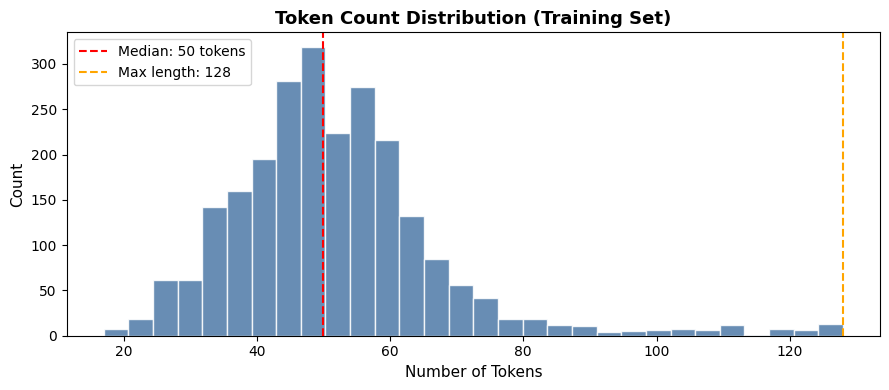

Median tokens per example: 50
Examples at max length (128): 12 (0.5%)


In [17]:
# Compute number of real tokens (non-padding) per example
token_counts = [int(ex["attention_mask"].sum()) for ex in tokenized_datasets["train"]]

plt.figure(figsize=(9, 4))
plt.hist(token_counts, bins=30, color="#4e79a7", edgecolor="white", alpha=0.85)
plt.axvline(np.median(token_counts), color="red", linestyle="--",
            label=f"Median: {int(np.median(token_counts))} tokens")
plt.axvline(MAX_LENGTH, color="orange", linestyle="--",
            label=f"Max length: {MAX_LENGTH}")
plt.title("Token Count Distribution (Training Set)", fontsize=13, fontweight="bold")
plt.xlabel("Number of Tokens", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("token_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median tokens per example: {int(np.median(token_counts))}")
print(f"Examples at max length ({MAX_LENGTH}): {sum(c >= MAX_LENGTH for c in token_counts)} "
      f"({100*sum(c >= MAX_LENGTH for c in token_counts)/len(token_counts):.1f}%)")

## 🤖 Phase 4: Model Setup

### Load Pre-trained Model

In [18]:
# Create label mappings
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}
id2label = {i: label for i, label in enumerate(LABEL_NAMES)}

print(f"Loading model: {MODEL_NAME}")
print("(This downloads the pre-trained model weights...)\n")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

# GPT FIX 3: Tell the model which token ID is the pad token.
# GPT has no built-in pad_token_id, so we set it here to match the tokenizer.
# Without this, GPT can't correctly mask out padding during the forward pass.
model.config.pad_token_id = tokenizer.pad_token_id

model.to(device)
print(f"\n✅ Model loaded and moved to {device}!")

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1`.


Loading model: distilgpt2
(This downloads the pre-trained model weights...)



model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded and moved to cuda!


### Model Information

In [19]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Information:")
print("=" * 60)
print(f"Model architecture: {model.config.model_type}")
print(f"Number of classes:  {NUM_LABELS}")
print(f"Labels:             {LABEL_NAMES}")
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size:           ~{total_params * 4 / 1e6:.1f} MB (float32)")
print(f"\nPad token ID:  {model.config.pad_token_id}")
print(f"EOS token ID:  {tokenizer.eos_token_id}")
print(f"(They are equal: {model.config.pad_token_id == tokenizer.eos_token_id})")

print("\nLabel mappings:")
for k, v in id2label.items():
    print(f"  {k} -> {v}")

Model Information:
Model architecture: gpt2
Number of classes:  4
Labels:             ['World', 'Sports', 'Business', 'Sci/Tech']

Total parameters:     81,915,648
Trainable parameters: 81,915,648
Model size:           ~327.7 MB (float32)

Pad token ID:  50256
EOS token ID:  50256
(They are equal: True)

Label mappings:
  0 -> World
  1 -> Sports
  2 -> Business
  3 -> Sci/Tech


### Architecture Summary

Let's look at the key layers of the model to understand its structure.

In [20]:
print("DistilGPT2 Architecture Summary:")
print("=" * 60)
print(model)
print("\nKey components:")
print("  - transformer.wte   : Word token embeddings")
print("  - transformer.wpe   : Word position embeddings")
print("  - transformer.h     : 6 transformer blocks (decoder layers)")
print("  - transformer.h.*.attn : Causal self-attention")
print("  - transformer.h.*.mlp  : Feed-forward network")
print("  - score             : Classification head (new, randomly initialized)")

DistilGPT2 Architecture Summary:
GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=4, bias=False)
)

Key component

## 🏡 Phase 5: Training Setup

### Define Metrics Function

In [21]:
# Load evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    """
    Compute accuracy and F1 metrics.
    Called automatically by Trainer after each epoch.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy   = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_weighted = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    f1_macro    = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy":    accuracy["accuracy"],
        "f1_weighted": f1_weighted["f1"],
        "f1_macro":    f1_macro["f1"]
    }

print("✅ Metrics function defined!")

✅ Metrics function defined!


### Configure Training Arguments

These training arguments are **identical to the BERT notebook** so you can compare results fairly.

> **Note**: In 2026, use `eval_strategy` instead of the old `evaluation_strategy`.

In [22]:
# Determine mixed precision support
# Mixed precision: bf16/fp16 only on CUDA (MPS/CPU run full precision)
use_bf16 = device.type == "cuda" and torch.cuda.is_bf16_supported()
use_fp16 = device.type == "cuda" and not use_bf16
# Fused optimizer is CUDA-only; fall back to standard AdamW elsewhere
OPTIMIZER = "adamw_torch_fused" if device.type == "cuda" else "adamw_torch"

training_args = TrainingArguments(
    output_dir="./gpt-news-model",

    # Hyperparameters (identical to BERT notebook)
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,

    # Evaluation (2026 standard: eval_strategy, not evaluation_strategy)
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",

    # Mixed precision
    fp16=use_fp16,
    bf16=use_bf16,

    # Optimizer (2026 standard)
    optim=OPTIMIZER,

    # Logging
    logging_steps=50,
    report_to="none",

    # Reproducibility
    seed=SEED,
)

print("Training Configuration:")
print("=" * 60)
print(f"Learning rate: {training_args.learning_rate}")
print(f"Batch size:    {training_args.per_device_train_batch_size}")
print(f"Epochs:        {training_args.num_train_epochs}")
print(f"Optimizer:     {training_args.optim}")
print(f"Mixed prec.:   {'bf16' if training_args.bf16 else 'fp16' if training_args.fp16 else 'none'}")
print(f"Evaluation:    {training_args.eval_strategy}")

Training Configuration:
Learning rate: 2e-05
Batch size:    16
Epochs:        3
Optimizer:     OptimizerNames.ADAMW_TORCH_FUSED
Mixed prec.:   bf16
Evaluation:    IntervalStrategy.EPOCH


### Initialize Trainer

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

steps_per_epoch = len(tokenized_datasets["train"]) // BATCH_SIZE
total_steps     = steps_per_epoch * NUM_EPOCHS

print("✅ Trainer initialized!\n")
print("Training Statistics:")
print("=" * 60)
print(f"Training samples:   {len(tokenized_datasets['train'])}")
print(f"Validation samples: {len(tokenized_datasets['validation'])}")
print(f"Steps per epoch:    {steps_per_epoch}")
print(f"Total steps:        {total_steps}")

✅ Trainer initialized!

Training Statistics:
Training samples:   2400
Validation samples: 400
Steps per epoch:    150
Total steps:        450


## 🚀 Phase 6: Training

In [24]:
print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print("\n⏳ Training in progress... (~3-4 minutes on T4 GPU)\n")

train_result = trainer.train()

print("\n" + "=" * 60)
print("TRAINING COMPLETED! 🎉")
print("=" * 60)


STARTING TRAINING

⏳ Training in progress... (~3-4 minutes on T4 GPU)



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.604658,0.487468,0.827500,0.826198,0.825741
2,0.376572,0.405818,0.865000,0.864148,0.863684
3,0.373197,0.374290,0.877500,0.876910,0.876344


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETED! 🎉


### Training Results

In [25]:
print("\nTraining Results:")
print("-" * 60)
for key, value in train_result.metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")


Training Results:
------------------------------------------------------------
train_runtime: 122.9822
train_samples_per_second: 58.5450
train_steps_per_second: 3.6590
total_flos: 235184062464000.0000
train_loss: 0.6008
epoch: 3.0000


### Training Loss Curve

A decreasing training loss confirms the model is learning. If it plateaus or increases, consider adjusting the learning rate.

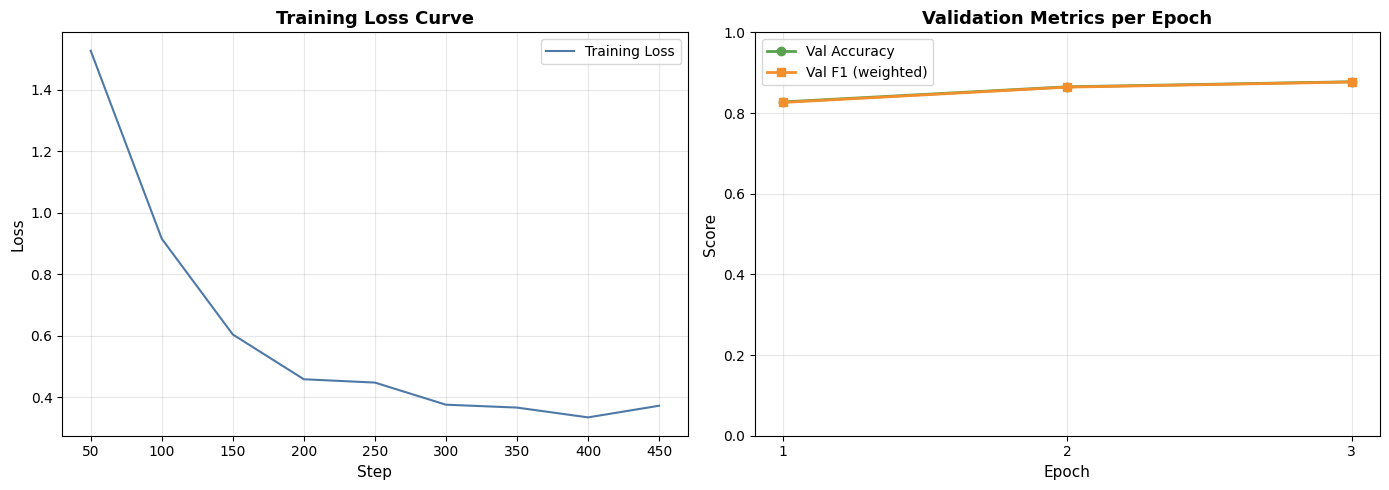

📊 Training curves saved as 'training_curves.png'


In [26]:
# Extract training log
log_history = trainer.state.log_history

# Separate training loss entries from eval entries
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

if train_logs:
    train_df_log = pd.DataFrame(train_logs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training loss
    axes[0].plot(train_df_log["step"], train_df_log["loss"],
                 color="#4e79a7", linewidth=1.5, label="Training Loss")
    axes[0].set_title("Training Loss Curve", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Step", fontsize=11)
    axes[0].set_ylabel("Loss", fontsize=11)
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # Validation metrics per epoch
    if eval_logs:
        eval_df_log = pd.DataFrame(eval_logs)
        epochs = range(1, len(eval_df_log) + 1)
        axes[1].plot(epochs, eval_df_log["eval_accuracy"],
                     marker="o", color="#59a14f", linewidth=2, label="Val Accuracy")
        axes[1].plot(epochs, eval_df_log["eval_f1_weighted"],
                     marker="s", color="#f28e2b", linewidth=2, label="Val F1 (weighted)")
        axes[1].set_title("Validation Metrics per Epoch", fontsize=13, fontweight="bold")
        axes[1].set_xlabel("Epoch", fontsize=11)
        axes[1].set_ylabel("Score", fontsize=11)
        axes[1].set_xticks(list(epochs))
        axes[1].set_ylim(0, 1)
        axes[1].grid(alpha=0.3)
        axes[1].legend()

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("📊 Training curves saved as 'training_curves.png'")
else:
    print("No training log entries found.")

### Per-Epoch Metrics Table

In [27]:
if eval_logs:
    eval_df_log = pd.DataFrame(eval_logs)
    cols = ["epoch", "eval_loss", "eval_accuracy", "eval_f1_weighted", "eval_f1_macro"]
    available = [c for c in cols if c in eval_df_log.columns]
    summary = eval_df_log[available].copy()
    summary.columns = [c.replace("eval_", "") for c in available]
    summary.index = [f"Epoch {i+1}" for i in range(len(summary))]
    print("Validation Metrics per Epoch:")
    print("=" * 60)
    print(summary.to_string(float_format="{:.4f}".format))
else:
    print("No validation logs found.")

Validation Metrics per Epoch:
         epoch   loss  accuracy  f1_weighted  f1_macro
Epoch 1 1.0000 0.4875    0.8275       0.8262    0.8257
Epoch 2 2.0000 0.4058    0.8650       0.8641    0.8637
Epoch 3 3.0000 0.3743    0.8775       0.8769    0.8763


## 📊 Phase 7: Evaluation

### Evaluate on Test Set

In [28]:
print("Evaluating on test set...\n")

test_results = trainer.evaluate(tokenized_datasets["test"])

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")

Evaluating on test set...



Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted,F1 Macro
0.373197,0.271670,3,0.900000,0.900188,0.900470


TEST SET RESULTS
eval_loss: 0.2717
eval_accuracy: 0.9000
eval_f1_weighted: 0.9002
eval_f1_macro: 0.9005


### Detailed Classification Report

In [29]:
print("Generating predictions for detailed analysis...\n")

predictions_output = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions_output.predictions, axis=-1)
labels      = predictions_output.label_ids

print("Classification Report (per class):")
print("=" * 60)
print(classification_report(labels, predictions, target_names=LABEL_NAMES))

Generating predictions for detailed analysis...



Classification Report (per class):
              precision    recall  f1-score   support

       World       0.91      0.91      0.91       245
      Sports       0.97      0.96      0.97       250
    Business       0.85      0.86      0.86       257
    Sci/Tech       0.87      0.87      0.87       248

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



### Confusion Matrix

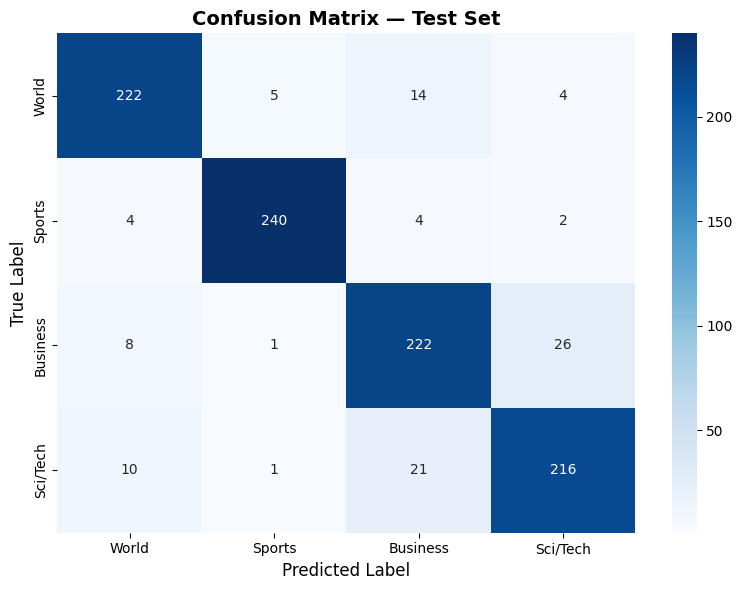

📊 Confusion matrix saved as 'confusion_matrix.png'


In [30]:
cm = confusion_matrix(labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Confusion matrix saved as 'confusion_matrix.png'")

### Per-Class Accuracy

Per-Class Accuracy:
World     : 90.61%  ███████████████████████████
Sports    : 96.00%  ████████████████████████████
Business  : 86.38%  █████████████████████████
Sci/Tech  : 87.10%  ██████████████████████████


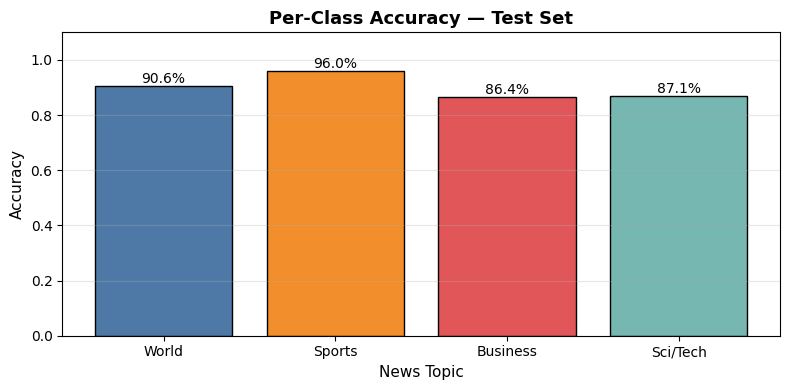

In [31]:
true_counts = cm.sum(axis=1)
class_accuracies = np.where(true_counts == 0, 0, cm.diagonal() / true_counts)

print("Per-Class Accuracy:")
print("=" * 40)
for name, acc in zip(LABEL_NAMES, class_accuracies):
    bar = "█" * int(acc * 30)
    print(f"{name:10s}: {acc:.2%}  {bar}")

# Bar chart
plt.figure(figsize=(8, 4))
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]
bars = plt.bar(LABEL_NAMES, class_accuracies, color=colors, edgecolor="black")
plt.bar_label(bars, fmt="%.1f%%", label_type="edge",
              labels=[f"{a:.1%}" for a in class_accuracies])
plt.title("Per-Class Accuracy — Test Set", fontsize=13, fontweight="bold")
plt.xlabel("News Topic", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.ylim(0, 1.1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 🎯 Phase 8: Inference (Making Predictions)

### Define Prediction Function

In [32]:
def predict_topic(text, model, tokenizer, device):
    """
    Predict news topic for a single headline or article snippet.

    Args:
        text:      Input text string
        model:     Trained GPT classification model
        tokenizer: Configured GPT tokenizer (with pad_token set)
        device:    Torch device (cuda / cpu)

    Returns:
        Dictionary with predicted label, confidence, and all class probabilities.
    """
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs      = torch.softmax(outputs.logits, dim=-1)
        pred_class = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_class].item()

    return {
        "text":             text,
        "predicted_label":  LABEL_NAMES[pred_class],
        "predicted_id":     pred_class,
        "confidence":       confidence,
        "probabilities":    {LABEL_NAMES[i]: probs[0][i].item() for i in range(NUM_LABELS)}
    }

print("✅ predict_topic() function defined!")

✅ predict_topic() function defined!


### Test with Custom Headlines (One Per Topic)

In [33]:
# Four headlines, one per class
test_headlines = [
    # World
    "UN Security Council holds emergency session over escalating tensions in the Middle East",
    # Sports
    "Manchester United defeat Liverpool 3-1 in dramatic Premier League showdown",
    # Business
    "Federal Reserve raises interest rates by 25 basis points amid inflation concerns",
    # Sci/Tech
    "NASA's Artemis mission successfully deploys new lunar surface habitat module",
]

expected = ["World", "Sports", "Business", "Sci/Tech"]

print("Testing Model Predictions on Custom Headlines:")
print("=" * 80)

correct = 0
for i, (text, exp) in enumerate(zip(test_headlines, expected)):
    result = predict_topic(text, model, tokenizer, device)
    ok = "✅" if result["predicted_label"] == exp else "❌"

    print(f"\n{ok} Headline: \"{text[:70]}...\"")
    print(f"   Expected:  {exp}")
    print(f"   Predicted: {result['predicted_label']} (confidence: {result['confidence']:.1%})")
    print(f"   All probs: ", end="")
    for lbl, p in result["probabilities"].items():
        print(f"{lbl}: {p:.1%}", end="  ")
    print()
    if result["predicted_label"] == exp:
        correct += 1

print(f"\n{'='*80}")
print(f"Headline accuracy: {correct}/{len(test_headlines)}")

Testing Model Predictions on Custom Headlines:

✅ Headline: "UN Security Council holds emergency session over escalating tensions i..."
   Expected:  World
   Predicted: World (confidence: 57.6%)
   All probs: World: 57.6%  Sports: 0.0%  Business: 4.7%  Sci/Tech: 37.8%  

❌ Headline: "Manchester United defeat Liverpool 3-1 in dramatic Premier League show..."
   Expected:  Sports
   Predicted: World (confidence: 69.5%)
   All probs: World: 69.5%  Sports: 0.1%  Business: 10.6%  Sci/Tech: 19.8%  

❌ Headline: "Federal Reserve raises interest rates by 25 basis points amid inflatio..."
   Expected:  Business
   Predicted: World (confidence: 57.2%)
   All probs: World: 57.2%  Sports: 0.1%  Business: 11.3%  Sci/Tech: 31.4%  

✅ Headline: "NASA's Artemis mission successfully deploys new lunar surface habitat ..."
   Expected:  Sci/Tech
   Predicted: Sci/Tech (confidence: 55.0%)
   All probs: World: 40.3%  Sports: 0.0%  Business: 4.7%  Sci/Tech: 55.0%  

Headline accuracy: 2/4


### Using Hugging Face Pipeline (Easier Method)

In [34]:
# The pipeline wraps tokenization + inference into one call
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device
)

test_text = "SpaceX launches 60 Starlink satellites into low Earth orbit"
result = classifier(test_text)

print(f"Text:       \"{test_text}\"")
print(f"Prediction: {result[0]['label']}")
print(f"Confidence: {result[0]['score']:.2%}")

Text:       "SpaceX launches 60 Starlink satellites into low Earth orbit"
Prediction: World
Confidence: 66.71%


## 💾 Phase 9: Save, Load and Push to Hub

### Save Model to Disk

In [35]:
save_directory = "./my-gpt-news-model"

trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"✅ Model saved to: {save_directory}")
print(f"   Saved files: {os.listdir(save_directory)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: ./my-gpt-news-model
   Saved files: ['config.json', 'tokenizer_config.json', 'tokenizer.json', 'model.safetensors', 'training_args.bin']


### Load Model from Disk and Verify

In [36]:
print("Testing model loading from disk...\n")

loaded_tokenizer = AutoTokenizer.from_pretrained(save_directory)
loaded_model     = AutoModelForSequenceClassification.from_pretrained(save_directory)
loaded_model.to(device)

# Quick sanity check
test_text = "Apple unveils new AI chip for the next generation of MacBook Pro"
result = predict_topic(test_text, loaded_model, loaded_tokenizer, device)

print(f"Text:       \"{test_text}\"")
print(f"Prediction: {result['predicted_label']}")
print(f"Confidence: {result['confidence']:.2%}")
print("\n✅ Model loaded from disk and working correctly!")

Testing model loading from disk...



Loading weights:   0%|          | 0/77 [00:00<?, ?it/s]

Text:       "Apple unveils new AI chip for the next generation of MacBook Pro"
Prediction: Sci/Tech
Confidence: 69.18%

✅ Model loaded from disk and working correctly!


### (Optional) Push to Hugging Face Hub

You can share your fine-tuned model with the world by pushing it to Hugging Face Hub.

> You'll need a free account at [huggingface.co](https://huggingface.co) and an access token.

In [40]:
PUSH_TO_HUB = True # <-- set True to push your fine-tuned model to Hugging Face Hub

if PUSH_TO_HUB:
    from huggingface_hub import login
    login()  # Enter your HF token when prompted
else:
    print("Skipping HF login (set PUSH_TO_HUB = True to enable)")


In [41]:
# Push your model to the Hub (set PUSH_TO_HUB = True above to enable)
YOUR_USERNAME = "msaifee"  # <-- change this

if PUSH_TO_HUB:
    trainer.push_to_hub(f"{YOUR_USERNAME}/gpt-news-classifier123")
    tokenizer.push_to_hub(f"{YOUR_USERNAME}/gpt-news-classifier123")

    print("💡 Your model is now publicly available at:")
    print("   https://huggingface.co/YOUR_USERNAME/gpt-news-classifier")
else:
    print("Skipping push to Hub (set PUSH_TO_HUB = True to enable)")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💡 Your model is now publicly available at:
   https://huggingface.co/YOUR_USERNAME/gpt-news-classifier


## 📝 Summary

In [39]:
print("\n" + "=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)

accuracy   = test_results.get("eval_accuracy",    0)
f1_weighted = test_results.get("eval_f1_weighted", 0)
f1_macro   = test_results.get("eval_f1_macro",    0)

print(f"""
Model Configuration:
  - Base Model:  {MODEL_NAME}  (~82M parameters)
  - Task:        4-class news topic classification
  - Labels:      {LABEL_NAMES}
  - Dataset:     AG News ({TRAIN_SIZE} train / {VAL_SIZE} val / {TEST_SIZE} test)

Performance (Test Set):
  - Accuracy:    {accuracy:.2%}
  - F1 Weighted: {f1_weighted:.2%}
  - F1 Macro:    {f1_macro:.2%}

Training Setup:
  - Epochs:      {NUM_EPOCHS}
  - Batch size:  {BATCH_SIZE}
  - LR:          {LEARNING_RATE}

GPT-Specific Fixes Applied:
  1. tokenizer.pad_token = tokenizer.eos_token
  2. tokenizer.padding_side = 'left'
  3. model.config.pad_token_id = tokenizer.pad_token_id

Files Generated:
  - ./my-gpt-news-model/   (saved model)
  - class_distribution.png
  - token_distribution.png
  - training_curves.png
  - confusion_matrix.png
  - per_class_accuracy.png
""")

print("=" * 70)
print("🎉 CONGRATULATIONS! You've successfully fine-tuned a GPT model!")
print("=" * 70)


TRAINING SUMMARY

Model Configuration:
  - Base Model:  distilgpt2  (~82M parameters)
  - Task:        4-class news topic classification
  - Labels:      ['World', 'Sports', 'Business', 'Sci/Tech']
  - Dataset:     AG News (2400 train / 400 val / 1000 test)

Performance (Test Set):
  - Accuracy:    90.00%
  - F1 Weighted: 90.02%
  - F1 Macro:    90.05%

Training Setup:
  - Epochs:      3
  - Batch size:  16
  - LR:          2e-05

GPT-Specific Fixes Applied:
  1. tokenizer.pad_token = tokenizer.eos_token
  2. tokenizer.padding_side = 'left'
  3. model.config.pad_token_id = tokenizer.pad_token_id

Files Generated:
  - ./my-gpt-news-model/   (saved model)
  - class_distribution.png
  - token_distribution.png
  - training_curves.png
  - confusion_matrix.png
  - per_class_accuracy.png

🎉 CONGRATULATIONS! You've successfully fine-tuned a GPT model!


## 🚀 Next Steps

1. **Try a larger GPT model**: Change `MODEL_NAME = "gpt2"` (124M params) for potentially better accuracy.

2. **Try GPT-Neo**: `EleutherAI/gpt-neo-125m` — similar size, different architecture.

3. **Text generation**: Now that you understand GPT classification, try `AutoModelForCausalLM` to generate news headlines in a given topic.

4. **Experiment with hyperparameters**:
   ```python
   LEARNING_RATE = 1e-5   # Try lower learning rate
   MAX_LENGTH = 256       # Longer context for better understanding
   NUM_EPOCHS = 5         # More epochs
   ```

5. **Compare with BERT**: Run the companion BERT notebook on the same AG News dataset and compare accuracy, F1, and training time.

6. **Upload to Hugging Face Hub**: Share your model and let others use it!

---
**Happy Fine-Tuning! 🎯**

## 🔄 BERT vs GPT — Final Comparison

After completing both notebooks, here's a summary of what you should have observed:

| Comparison Point | BERT Notebook | GPT Notebook (this one) |
|-----------------|---------------|-------------------------|
| **Model** | `distilbert-base-uncased` | `distilgpt2` |
| **Parameters** | ~66M | ~82M |
| **Architecture** | Encoder (bidirectional) | Decoder (causal/left-to-right) |
| **Dataset** | Tweet Sentiment (3 classes) | AG News (4 classes) |
| **Dataset difficulty** | Moderate (tweets are noisy) | Easy (clean newswire text) |
| **Test accuracy** | ~68% (expected for tweets) | ~90%+ (expected for AG News) |
| **Training time (T4)** | ~2 min | ~3-4 min |
| **Special setup needed** | None | pad_token + left-padding |
| **Best for classification** | ✅ Natural fit (uses [CLS]) | ⚠️ Works but not its primary design |
| **Best for generation** | ❌ Not designed for it | ✅ Primary strength |

### 💡 Key Takeaway

> **BERT-style encoders** (BERT, DistilBERT, RoBERTa) are generally **better at classification** tasks because they see the full context in both directions. **GPT-style decoders** (GPT-2, LLaMA, Mistral) are **better at generation** tasks, but can be fine-tuned for classification with a few extra setup steps — which is exactly what you did in this notebook!